## Setup

In [177]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

REPORTS_DIR = Path.cwd() / "reports"

In [178]:
palette = [
    "#0072B2",
    "#6EC6F0",
    "#1A3A6B",
    "#77D4CC",
    "#009E73",
    "#44AA99",
    "#F2E55C",
    "#E69F00",
    "#556B00",
    "#D4669A",
    "#CC3311",
    "#DDDDDD",
    "#222222",
    "#882255"
]

cmap = mcolors.ListedColormap(palette, name="custom")

## Load Reports

In [179]:
def load_reports(report_dir):
    reports = {}
    for p in report_dir.glob("*_build_status.json"):
        repo = p.stem.replace("_build_status", "")
        with p.open() as f: raw = json.load(f)
        reports[repo] = raw["report"]
    return reports

reports = load_reports(REPORTS_DIR)
print("repos:", len(reports))

repos: 9


## Convert to DataFrames

In [180]:
def flatten_totals(reports):
    rows = []
    for repo, row in reports.items():
        report = row if "totals" in row else row["report"]
        section_labels = report["labels"]["sections"]
        field_labels = report["labels"]["fields"]
        for section, metrics in report["totals"].items():
            section_label = section_labels[section]
            for metric, value in metrics.items():
                metric_label = field_labels[metric]
                rows.append({
                    "repo": repo,
                    "section": section_label,
                    "metric": metric_label,
                    "value": value
                })
        section_timing = "Timing"
        report = row if "timing" in row else row["report"]
        phase_labels = report["labels"]["phases"]
        rows.append({
            "repo": repo,
            "section": section_timing,
            "metric": field_labels["build_total_seconds"],
            "value": report["timing"]["build_total_seconds"]
        })
        rows.append({
            "repo": repo,
            "section": section_timing,
            "metric": field_labels["build_wall_seconds"],
            "value": report["timing"]["build_wall_seconds"]
        })
        for phase, time in report["timing"]["build_phase_timings"].items():
            rows.append({
                "repo": repo,
                "section": section_timing,
                "metric": phase_labels[phase],
                "value": time
            })

    return pd.DataFrame(rows)

totals_df= flatten_totals(reports)

In [181]:
def flatten_scopes(reports):
    rows = []
    for repo, row in reports.items():
        report = row if "scopes" in row else row["report"]
        section_labels = report["labels"]["sections"]
        field_labels = report["labels"]["fields"]
        scope_labels = report["labels"]["scopes"]
        for scope, sections in report["scopes"].items():
            scope_label = scope_labels[scope]
            for section, metrics in sections.items():
                section_label = section_labels[section]
                for metric, value in metrics.items():
                    metric_label = field_labels[metric]
                    rows.append({
                        "repo": repo,
                        "scope": scope_label,
                        "section": section_label,
                        "metric": metric_label,
                        "value": value
                    })

    return pd.DataFrame(rows)

scopes_df= flatten_scopes(reports)

In [182]:
def flatten_languages(reports):
    rows = []
    for repo, row in reports.items():
        report = row if "languages" in row else row["report"]
        section_labels = report["labels"]["sections"]
        field_labels = report["labels"]["fields"]
        for language, sections in report["languages"].items():
            language_label = language
            for section, metrics in sections.items():
                section_label = section_labels[section]
                for metric, value in metrics.items():
                    metric_label = field_labels[metric]
                    rows.append({
                        "repo": repo,
                        "language": language_label,
                        "section": section_label,
                        "metric": metric_label,
                        "value": value
                    })

    return pd.DataFrame(rows)

languages_df= flatten_languages(reports)

## Service functions

In [183]:
def df_section(df, section):
    subset = df[df.section == section]
    return subset.pivot(index="repo", columns="metric", values="value")

## Overview

In [184]:
totals_pivot = totals_df.pivot(
    index="repo",
    columns=["section","metric"],
    values="value")

totals_pivot

section      Call Materialization                               Callsites  \
metric             Callsite Pairs Finalized Call Edges Accepted Callsites   
repo                                                                        
airbyte                   14988.0              14148.0            14976.0   
commons-lang               5718.0               5713.0             5376.0   
eslint                      709.0                708.0              709.0   
guava                     36099.0              36064.0            34844.0   
nodebb                     3494.0               3425.0             3494.0   
npm-cli                    5430.0               5425.0             5430.0   
pydantic                   2717.0               2708.0             2717.0   
rollup                     8377.0               8335.0             8130.0   
sympy                     61673.0              61122.0            60213.0   

section                                                           \
metric       Not Accepted Callsites Observed Syntactic Callsites   
repo                                                               
airbyte                       650.0                      15626.0   
commons-lang                  316.0                       5692.0   
eslint                         36.0                        745.0   
guava                        1795.0                      36639.0   
nodebb                       2405.0                       5899.0   
npm-cli                       274.0                       5704.0   
pydantic                      546.0                       3263.0   
rollup                       3729.0                      11859.0   
sympy                       12450.0                      72663.0   

section            Not Accepted Callsites                          \
metric       Insufficient Static Evidence Outside Static Contract   
repo                                                                
airbyte                             182.0                    73.0   
commons-lang                         20.0                     0.0   
eslint                               26.0                     7.0   
guava                                10.0                     0.0   
nodebb                              913.0                   103.0   
npm-cli                             227.0                     2.0   
pydantic                            397.0                     0.0   
rollup                             3636.0                    43.0   
sympy                             11031.0                     5.0   

section                                       Structure  ...  \
metric       Structural Mismatch Unclassified     Edges  ...   
repo                                                     ...   
airbyte                     91.0        346.0   38598.0  ...   
commons-lang               185.0        205.0   17316.0  ...   
eslint                       0.0         33.0    3126.0  ...   
guava                     1256.0       1266.0  103280.0  ...   
nodebb                       0.0       1016.0    8675.0  ...   
npm-cli                      0.0        229.0   15174.0  ...   
pydantic                     0.0        397.0   16727.0  ...   
rollup                       6.0       3685.0   20514.0  ...   
sympy                       11.0      11047.0  113755.0  ...   

section                         Timing                            \
metric       Compute Build Fingerprint Extract Call Observations   
repo                                                               
airbyte                       0.589666                 16.975549   
commons-lang                  0.505759                  5.892010   
eslint                        0.291243                  9.144657   
guava                         1.382440                 32.187675   
nodebb                        0.318990                  5.786722   
npm-cli                       0.578873                 11.735284   
pydantic                      0.432866          

In [185]:
timing_total_df = df_section(totals_df, "Timing")[["Build Wall Time"]]
timing_total_df = timing_total_df.sort_values("Build Wall Time", ascending=True)
timing_total_df = timing_total_df.join(df_section(totals_df, "Structure")[["Nodes", "Edges"]])
timing_total_df["Nodes + Edges"] = timing_total_df["Nodes"] + timing_total_df["Edges"]
timing_total_df["Time per 1K Nodes"] = timing_total_df["Build Wall Time"] / (timing_total_df["Nodes"] / 1000)
timing_total_df["Time per 1K Edges"] = timing_total_df["Build Wall Time"] / (timing_total_df["Edges"] / 1000)
timing_total_df["Time per 1K (Nodes + Edges)"] = timing_total_df["Build Wall Time"] / (timing_total_df["Nodes + Edges"] / 1000)

timing_mean = timing_total_df.mean(numeric_only=True)
timing_median = timing_total_df.median(numeric_only=True)
timing_std = timing_total_df.std(numeric_only=True)

timing_mean.name = "Mean"
timing_median.name = "Median"
timing_std.name = "Std"

timing_overview_df = pd.concat([timing_total_df, timing_mean.to_frame().T, timing_std.to_frame().T, timing_median.to_frame().T]).round(2)
timing_overview_df

metric,Build Wall Time,Nodes,Edges,Nodes + Edges,Time per 1K Nodes,Time per 1K Edges,Time per 1K (Nodes + Edges)
nodebb,16.50,3349.00,8675.00,12024.00,4.93,1.90,1.37
commons-lang,20.22,11566.00,17316.00,28882.00,1.75,1.17,0.70
eslint,22.20,3115.00,3126.00,6241.00,7.13,7.10,3.56
pydantic,22.39,13301.00,16727.00,30028.00,1.68,1.34,0.75
npm-cli,32.86,9752.00,15174.00,24926.00,3.37,2.17,1.32
airbyte,59.09,25275.00,38598.00,63873.00,2.34,1.53,0.93
rollup,68.09,19675.00,20514.00,40189.00,3.46,3.32,1.69
guava,124.68,64135.00,103280.00,167415.00,1.94,1.21,0.74
sympy,250.27,40980.00,113755.00,154735.00,6.11,2.20,1.62
Mean,68.48,21238.67,37462.78,58701.44,3.63,2.44,1.41


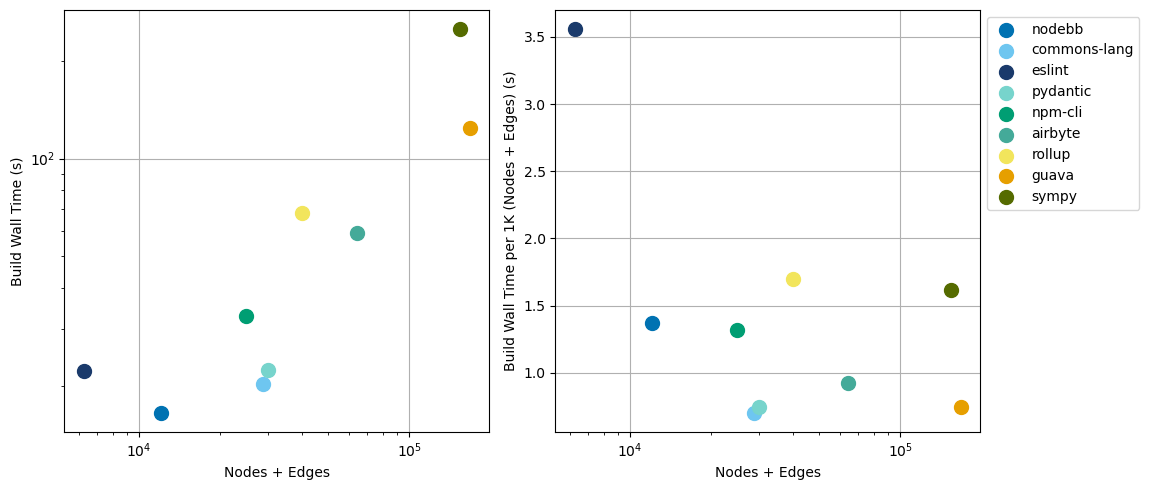

In [186]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True)

for i, repo in enumerate(timing_total_df.index):
    color = palette[i % len(palette)]
    x = timing_total_df.loc[repo, "Nodes + Edges"]
    y1 = timing_total_df.loc[repo, "Build Wall Time"]
    y2 = timing_total_df.loc[repo, "Time per 1K (Nodes + Edges)"]

    axes[0].scatter(x, y1, color=color, s=100, label=repo)
    axes[1].scatter(x, y2, color=color, s=100)

axes[0].set_xlabel("Nodes + Edges")
axes[0].set_ylabel("Build Wall Time (s)")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].grid(True)

axes[1].set_xlabel("Nodes + Edges")
axes[1].set_ylabel("Build Wall Time per 1K (Nodes + Edges) (s)")
axes[1].set_xscale("log")
axes[1].grid(True)

fig.legend(loc="upper left", bbox_to_anchor=(0.985, 0.97))
plt.tight_layout()
plt.show()

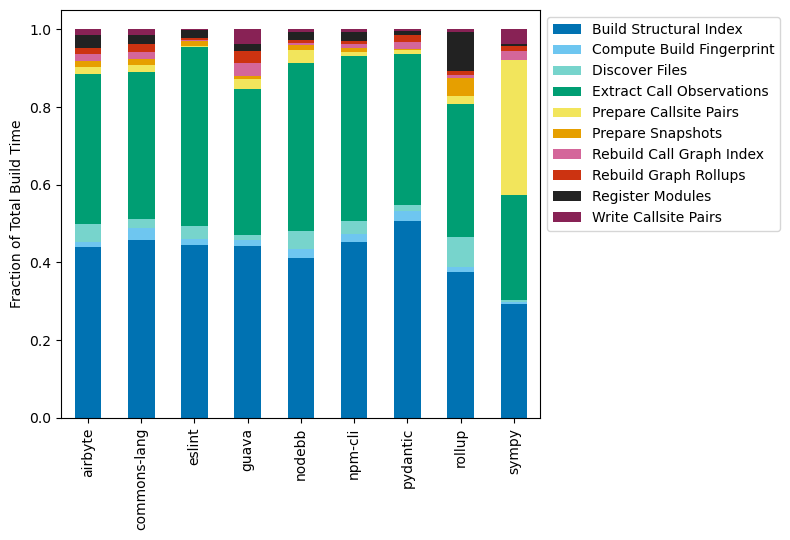

In [187]:
timing_phases_df = df_section(totals_df, "Timing").drop(columns=["Build Total Time", "Build Wall Time", "Diagnostic Classification"], errors="ignore")
timing_phases_df = timing_phases_df.div(timing_phases_df.sum(axis=1), axis=0)

timing_phases_df.plot( kind="bar", stacked=True, colormap=cmap, figsize=(8, 5.5))
plt.legend(bbox_to_anchor=(1, 1), loc="upper left")
plt.xlabel("")
plt.ylabel("Fraction of Total Build Time")
plt.tight_layout()
plt.show()

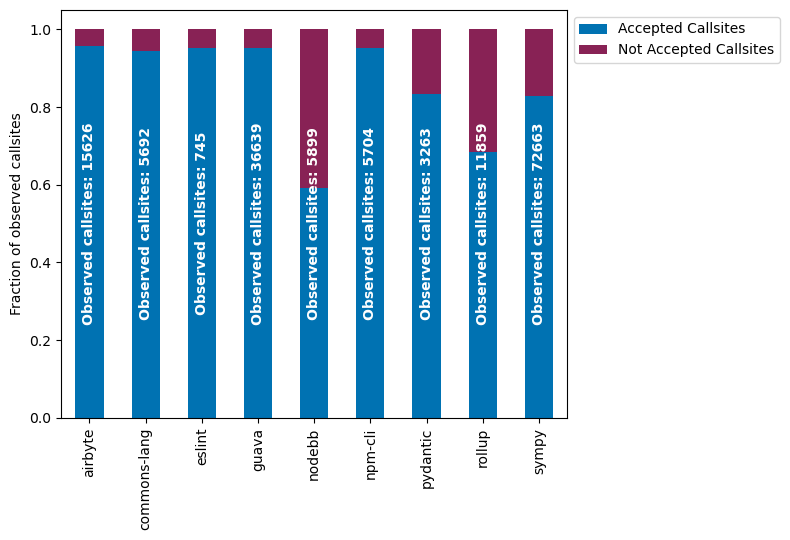

In [188]:
observed_callsites = df_section(totals_df, "Callsites")["Observed Syntactic Callsites"]

callsites_df = df_section(totals_df, "Callsites").drop(columns=["Observed Syntactic Callsites"])
callsites_df = callsites_df.div(callsites_df.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(8,5.5))

callsites_df.plot( kind="bar", stacked=True, colormap=cmap, ax=ax)

for i, (repo, value) in enumerate(observed_callsites.items()):
    ax.text(i, 0.5, f"Observed callsites: {int(value)}", rotation=90, ha="center", va="center", fontsize=10, fontweight="bold", color="white")

plt.legend(bbox_to_anchor=(1, 1), loc="upper left")
plt.xlabel("")
plt.ylabel("Fraction of observed callsites")
plt.tight_layout()
plt.show()

In [189]:
callsites_df

metric,Accepted Callsites,Not Accepted Callsites
repo,,
airbyte,0.958403,0.041597
commons-lang,0.944483,0.055517
eslint,0.951678,0.048322
guava,0.951008,0.048992
nodebb,0.592304,0.407696
npm-cli,0.951964,0.048036
pydantic,0.832669,0.167331
rollup,0.685555,0.314445
sympy,0.828661,0.171339


## Language breakdown

In [190]:
languages_pivot = languages_df.pivot(
    index=["repo","language"],
    columns=["section","metric"],
    values="value")
languages_pivot

section                 Call Materialization                       \
metric                        Callsite Pairs Finalized Call Edges   
repo         language                                               
airbyte      java                       1568                 1568   
             javascript                   53                   53   
             python                    13365                12525   
             typescript                    2                    2   
commons-lang java                       5718                 5713   
eslint       javascript                  709                  708   
             typescript                    0                    0   
guava        java                      36099                36064   
             javascript                    0                    0   
nodebb       javascript                 3494                 3425   
             typescript                    0                    0   
npm-cli      javascript                 4060                 4055   
             python                     1370                 1370   
pydantic     javascript                    8                    8   
             python                     2709                 2700   
rollup       javascript                 5991                 5991   
             typescript                 2386                 2344   
sympy        python                    61673                61122   

section                          Callsites                         \
metric                  Accepted Callsites Not Accepted Callsites   
repo         language                                               
airbyte      java                     1556                     67   
             javascript                 53                      0   
             python                  13365                    583   
             typescript                  2                      0   
commons-lang java                     5376                    316   
eslint       javascript                709                     36   
             typescript                  0                      0   
guava        java                    34844                   1795   
             javascript                  0                      0   
nodebb       javascript               3494                   2405   
             typescript                  0                      0   
npm-cli      javascript               4060                    249   
             python                   1370                     25   
pydantic     javascript                  8                      0   
             python                   2709                    546   
rollup       javascript               5991                   3509   
             typescript               2139                    220   
sympy        python                  60213                  12450   

section                                               \
metric                  Observed Syntactic Callsites   
repo         language                                  
airbyte      java                               1623   
             javascript                           53   
             python                            13948   
             typescript                            2   
commons-lang java                               5692   
eslint       javascript                          745   
             typescript                            0   
guava        java                              36639   
             javascript                            0   
nodebb       javascript                         5899   
             typescript                            0   
npm-cli      javascript                         4309   
             python                             1395   
pydantic     javascript                            8   
             python                             3255   
rollup       javascript                         9500   
             typescript             

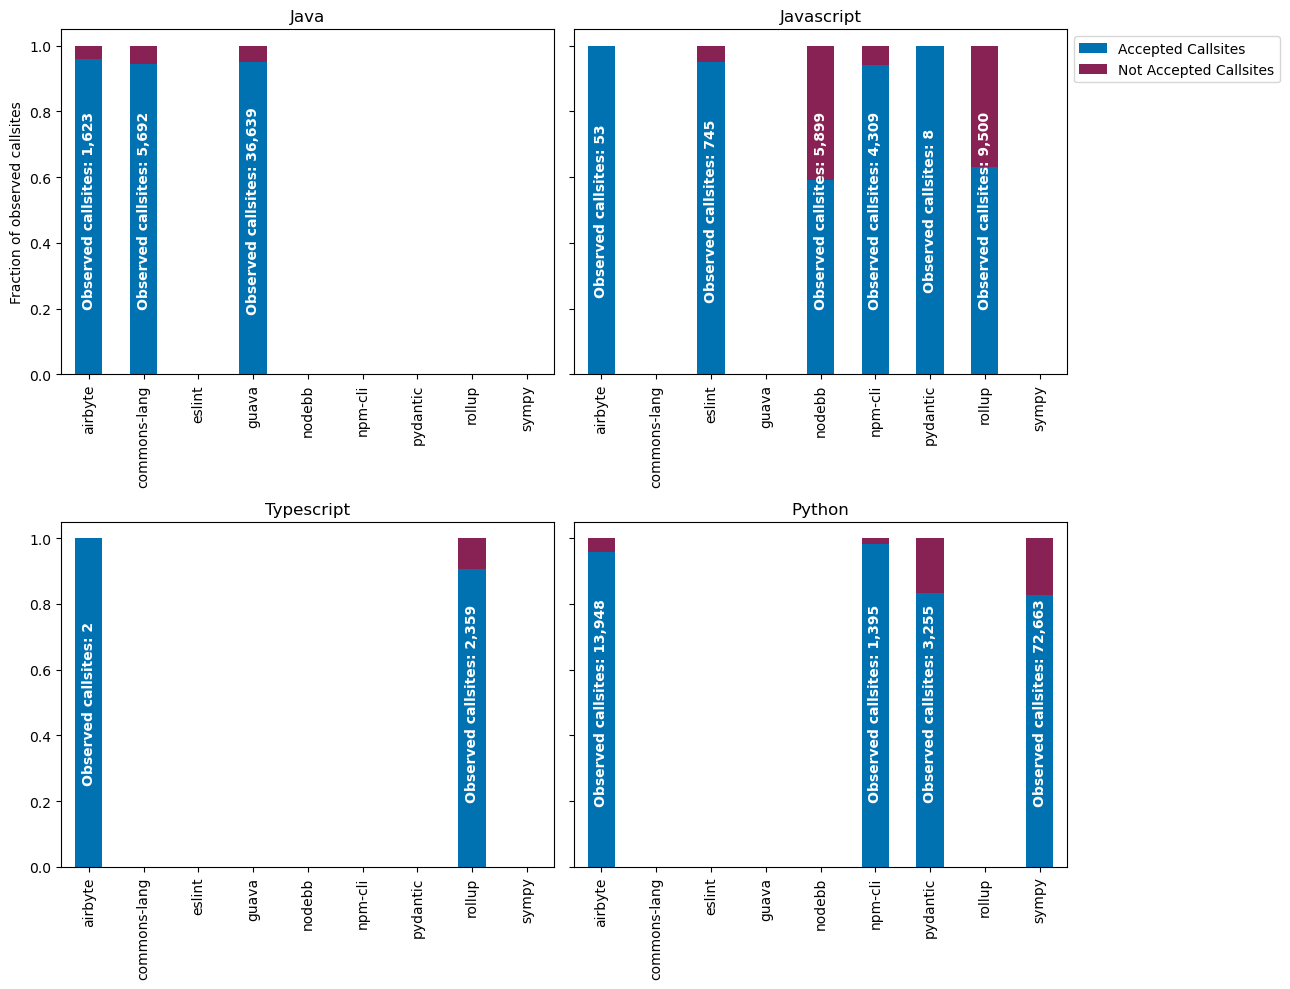

In [191]:
observed_callsites = languages_pivot.xs("Callsites", axis=1, level="section")["Observed Syntactic Callsites"]

callsites_df = languages_pivot.xs("Callsites", axis=1, level="section").drop(columns=["Observed Syntactic Callsites"])
callsites_df = callsites_df.div(callsites_df.sum(axis=1), axis=0)
callsites_df = callsites_df.sort_index(level="repo")

all_repos = callsites_df.index.get_level_values("repo").unique()

java_df = callsites_df.xs("java", level="language").reindex(all_repos, fill_value=0)
javascript_df = callsites_df.xs("javascript", level="language").reindex(all_repos, fill_value=0)
typescript_df = callsites_df.xs("typescript", level="language").reindex(all_repos, fill_value=0)
python_df = callsites_df.xs("python", level="language").reindex(all_repos, fill_value=0)

java_callsites = observed_callsites.xs("java", level="language").reindex(all_repos, fill_value=0)
javascript_callsites = observed_callsites.xs("javascript", level="language").reindex(all_repos, fill_value=0)
typescript_callsites = observed_callsites.xs("typescript", level="language").reindex(all_repos, fill_value=0)
python_callsites = observed_callsites.xs("python", level="language").reindex(all_repos, fill_value=0)

fig, axes = plt.subplots(2,2, figsize=(13,10), sharey=True)

java_df.plot(kind="bar", stacked=True, colormap=cmap, ax=axes[0,0], legend=False)
javascript_df.plot(kind="bar", stacked=True, colormap=cmap, ax=axes[0,1])
typescript_df.plot(kind="bar", stacked=True, colormap=cmap, ax=axes[1,0], legend=False)
python_df.plot(kind="bar", stacked=True, colormap=cmap, ax=axes[1,1], legend=False)

for i, (repo, value) in enumerate(java_callsites.items()):
    axes[0,0].text(i, 0.5, f"Observed callsites: {int(value):,}", rotation=90, ha="center", va="center", fontsize=10, fontweight="bold", color="white")

for i, (repo, value) in enumerate(javascript_callsites.items()):
    axes[0,1].text(i, 0.5, f"Observed callsites: {int(value):,}", rotation=90, ha="center", va="center", fontsize=10, fontweight="bold", color="white")

for i, (repo, value) in enumerate(typescript_callsites.items()):
    axes[1,0].text(i, 0.5, f"Observed callsites: {int(value):,}", rotation=90, ha="center", va="center", fontsize=10, fontweight="bold", color="white")

for i, (repo, value) in enumerate(python_callsites.items()):
    axes[1,1].text(i, 0.5, f"Observed callsites: {int(value):,}", rotation=90, ha="center", va="center", fontsize=10, fontweight="bold", color="white")

axes[0,0].set_title("Java")
axes[0,1].set_title("Javascript")
axes[1,0].set_title("Typescript")
axes[1,1].set_title("Python")

for ax in axes.flat: ax.set_xlabel("")
axes[0,0].set_ylabel("Fraction of observed callsites")
axes[0,1].legend(bbox_to_anchor=(1,1), loc="upper left")

plt.tight_layout()
plt.show()

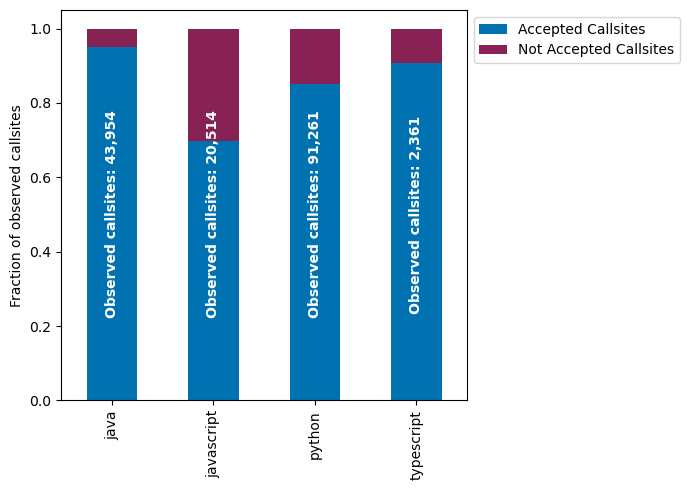

In [192]:
callsites_raw_df = languages_pivot.groupby(level="language").sum()
callsites_counts = callsites_raw_df.xs("Callsites", axis=1, level="section")["Observed Syntactic Callsites"]

callsites_df = languages_pivot.groupby(level="language").sum()
callsites_df = callsites_df.xs("Callsites", axis=1, level="section").drop(columns=["Observed Syntactic Callsites"])
callsites_df = callsites_df.div(callsites_df.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(7, 5))

callsites_df.plot( kind="bar", stacked=True, colormap=cmap, ax=ax)

for i, (lang, value) in enumerate(callsites_counts.items()):
    ax.text(i, 0.5, f"Observed callsites: {int(value):,}", rotation=90, ha="center", va="center", fontsize=10, fontweight="bold", color="white")

ax.legend(bbox_to_anchor=(1,1), loc="upper left")
ax.set_xlabel("")
ax.set_ylabel("Fraction of observed callsites")

plt.tight_layout()
plt.show()

In [193]:
callsites_raw_df

section    Call Materialization                               Callsites  \
metric           Callsite Pairs Finalized Call Edges Accepted Callsites   
language                                                                  
java                      43385                43345              41776   
javascript                14315                14240              14315   
python                    79117                77717              77657   
typescript                 2388                 2346               2141   

section                                                         \
metric     Not Accepted Callsites Observed Syntactic Callsites   
language                                                         
java                         2178                        43954   
javascript                   6199                        20514   
python                      13604                        91261   
typescript                    220                         2361   

section          Not Accepted Callsites                          \
metric     Insufficient Static Evidence Outside Static Contract   
language                                                          
java                                 46                       0   
javascript                         4658                     116   
python                            11604                      78   
typescript                          134                      39   

section                                     Structure                
metric     Structural Mismatch Unclassified     Edges  Files  Nodes  
language                                                             
java                      1479         1525    125989   4250  79839  
javascript                   0         4774     38224  16008  31973  
python                      64        11746    166301   4817  76687  
typescript                   6          179      6651    390   2649

In [194]:
callsites_df

metric,Accepted Callsites,Not Accepted Callsites
language,,
java,0.950448,0.049552
javascript,0.697816,0.302184
python,0.850933,0.149067
typescript,0.906819,0.093181


## Scope breakdown

In [195]:
scopes_pivot = scopes_df.pivot(
    index=["repo","scope"],
    columns=["section","metric"],
    values="value")
scopes_pivot

section                Call Materialization                       \
metric                       Callsite Pairs Finalized Call Edges   
repo         scope                                                 
airbyte      Non-Tests                14383                13543   
             Tests                      605                  605   
commons-lang Non-Tests                 3667                 3662   
             Tests                     2051                 2051   
eslint       Non-Tests                  693                  692   
             Tests                       16                   16   
guava        Non-Tests                24194                24159   
             Tests                    11905                11905   
nodebb       Non-Tests                 3468                 3401   
             Tests                       26                   24   
npm-cli      Non-Tests                 5278                 5273   
             Tests                      152                  152   
pydantic     Non-Tests                 1594                 1594   
             Tests                     1123                 1114   
rollup       Non-Tests                 2424                 2382   
             Tests                     5953                 5953   
sympy        Non-Tests                25205                25148   
             Tests                    36468                35974   

section                         Callsites                         \
metric                 Accepted Callsites Not Accepted Callsites   
repo         scope                                                 
airbyte      Non-Tests              14371                    641   
             Tests                    605                      9   
commons-lang Non-Tests               3325                     78   
             Tests                   2051                    238   
eslint       Non-Tests                693                     32   
             Tests                     16                      4   
guava        Non-Tests              22939                    617   
             Tests                  11905                   1178   
nodebb       Non-Tests               3468                   2402   
             Tests                     26                      3   
npm-cli      Non-Tests               5278                    274   
             Tests                    152                      0   
pydantic     Non-Tests               1594                    243   
             Tests                   1123                    303   
rollup       Non-Tests               2177                    227   
             Tests                   5953                   3502   
sympy        Non-Tests              24827                   3124   
             Tests                  35386                   9326   

section                                              \
metric                 Observed Syntactic Callsites   
repo         scope                                    
airbyte      Non-Tests                        15012   
             Tests                              614   
commons-lang Non-Tests                         3403   
             Tests                             2289   
eslint       Non-Tests                          725   
             Tests                               20   
guava        Non-Tests                        23556   
             Tests                            13083   
nodebb       Non-Tests                         5870   
             Tests                               29   
npm-cli      Non-Tests                         5552   
             Tests                              152   
pydantic     Non-Tests                         1837   
             Tests                             1426   
rollup       Non-Tests                         2404   
             Tests                             9455   
sympy        Non-Tests                        27951   
             Tests                        

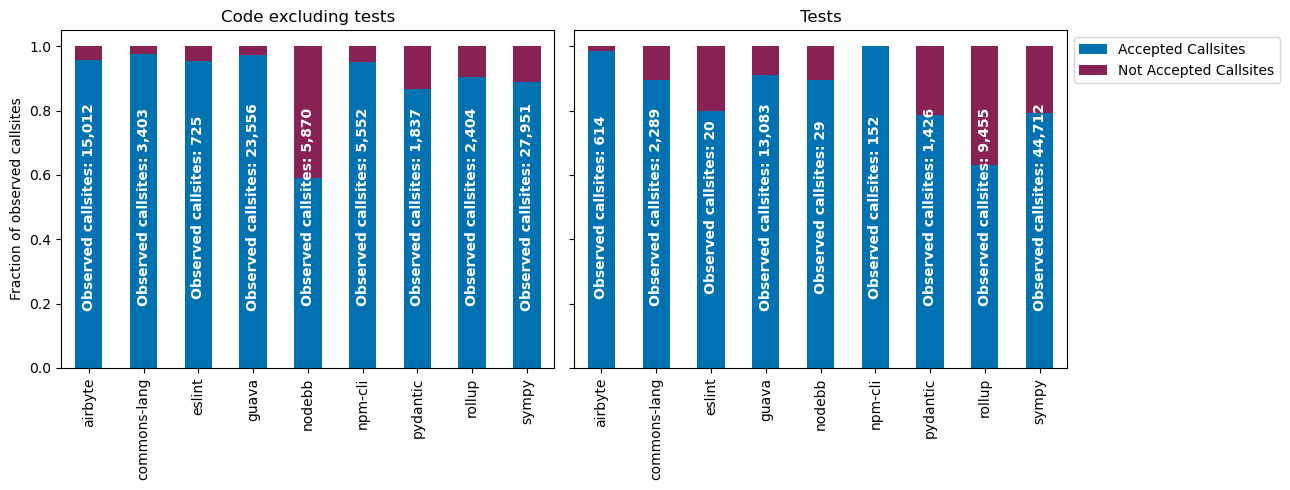

In [196]:
callsites_counts = scopes_pivot.xs("Callsites", axis=1, level="section")["Observed Syntactic Callsites"]
counts_non_tests = callsites_counts.xs("Non-Tests", level="scope")
counts_tests = callsites_counts.xs("Tests", level="scope")

callsites_df = scopes_pivot.xs("Callsites", axis=1, level="section").drop(columns=["Observed Syntactic Callsites"])
callsites_df = callsites_df.div(callsites_df.sum(axis=1), axis=0)
callsites_df = callsites_df.sort_index(level="repo")

non_test_df = callsites_df.xs("Non-Tests", level="scope")
tests_df = callsites_df.xs("Tests", level="scope")

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

non_test_df.plot(kind="bar", stacked=True, colormap=cmap, ax=axes[0],legend=False)
tests_df.plot(kind="bar", stacked=True, colormap=cmap, ax=axes[1])

for i, (repo, value) in enumerate(counts_non_tests.items()):
    axes[0].text(i, 0.5, f"Observed callsites: {int(value):,}", rotation=90, ha="center", va="center", fontsize=10, fontweight="bold", color="white")

for i, (repo, value) in enumerate(counts_tests.items()):
    axes[1].text(i, 0.5, f"Observed callsites: {int(value):,}", rotation=90, ha="center", va="center", fontsize=10, fontweight="bold", color="white")
    
axes[0].set_title("Code excluding tests")
axes[1].set_title("Tests")
axes[0].set_xlabel("")
axes[0].set_ylabel("Fraction of observed callsites")
axes[1].set_ylabel("")
axes[1].set_xlabel("")
axes[1].legend(bbox_to_anchor=(1,1),loc="upper left")
plt.tight_layout()
plt.show()

## Diagnostics

In [197]:
df_section(totals_df, "Not Accepted Callsites")

metric,Insufficient Static Evidence,Outside Static Contract,Structural Mismatch,Unclassified
repo,,,,
airbyte,182.0,73.0,91.0,346.0
commons-lang,20.0,0.0,185.0,205.0
eslint,26.0,7.0,0.0,33.0
guava,10.0,0.0,1256.0,1266.0
nodebb,913.0,103.0,0.0,1016.0
npm-cli,227.0,2.0,0.0,229.0
pydantic,397.0,0.0,0.0,397.0
rollup,3636.0,43.0,6.0,3685.0
sympy,11031.0,5.0,11.0,11047.0


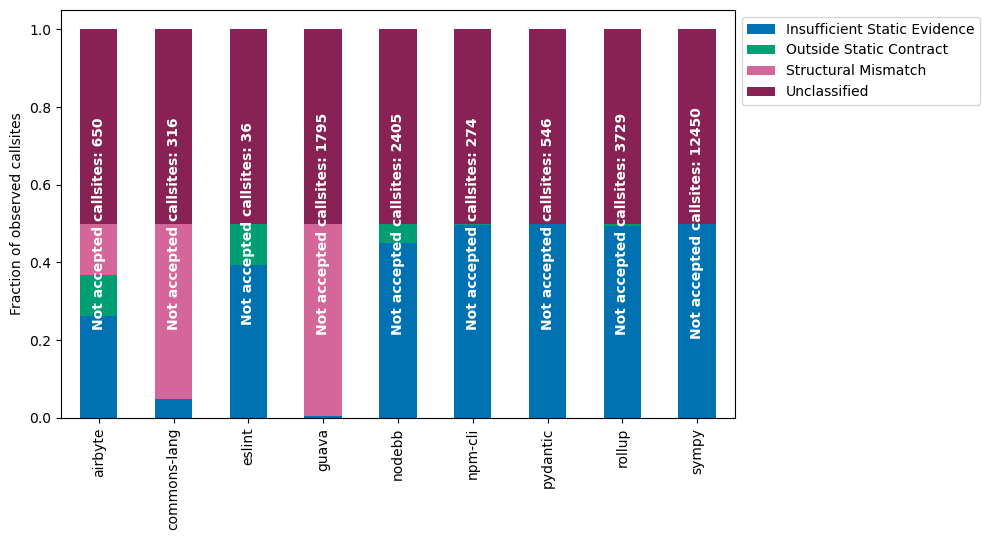

In [198]:
pre_persist = df_section(totals_df, "Callsites")["Not Accepted Callsites"]

pre_persist_df = df_section(totals_df, "Not Accepted Callsites")
pre_persist_df = pre_persist_df.div(pre_persist_df.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(10,5.5))

pre_persist_df.plot( kind="bar", stacked=True, colormap=cmap, ax=ax)

for i, (repo, value) in enumerate(pre_persist.items()):
    ax.text(i, 0.5, f"Not accepted callsites: {int(value)}", rotation=90, ha="center", va="center", fontsize=10, fontweight="bold", color="white")

plt.legend(bbox_to_anchor=(1, 1), loc="upper left")
plt.xlabel("")
plt.ylabel("Fraction of observed callsites")
plt.tight_layout()
plt.show()